In [62]:
import pandas as pd
import numpy as np
import requests
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from pandas.tseries.offsets import QuarterEnd


In [63]:
def fetch_data_fmp(ticker, api_key):
    url = f"https://financialmodelingprep.com/api/v3/historical-price-full/{ticker}?apikey={api_key}"
    response = requests.get(url)
    if response.status_code != 200:
        raise ValueError(f"Request failed with status code {response.status_code}")
    data = response.json()
    if "historical" not in data or not isinstance(data["historical"], list):
        raise ValueError(f"Unexpected response for {ticker}: {data}")
    records = data["historical"]
    df = pd.DataFrame(records)
    df = df[["date", "open", "high", "low", "close", "volume"]]
    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)
    df = df.sort_index()
    return df


In [64]:
def compute_indicators(df):
    df = df.rename(columns={
        'open': 'Open', 'high': 'High', 'low': 'Low', 'close': 'Close', 'volume': 'Volume'
    })
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -1 * delta.clip(upper=0)
    roll_up = gain.ewm(span=14).mean()
    roll_down = loss.ewm(span=14).mean()
    rs = roll_up / roll_down
    df['RSI'] = 100.0 - (100.0 / (1.0 + rs))
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    df['MACD'] = macd
    df['MACD_Signal'] = macd.ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    sma = df['Close'].rolling(window=20).mean()
    std = df['Close'].rolling(window=20).std()
    df['BB_Mid'] = sma
    df['BB_Upper'] = sma + 2 * std
    df['BB_Lower'] = sma - 2 * std
    df.dropna(inplace=True)
    return df


In [65]:
def prepare_data_quarterly_minmax(df, feature_cols, target_col='Close', window_size=60):
    df = df.copy()
    df['Quarter'] = df.index.to_period('Q')
    scaled_chunks, scalers = [], {}

    for quarter, group in df.groupby('Quarter'):
        chunk = group[feature_cols + [target_col]].copy()
        if len(chunk) < window_size:
            continue
        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(chunk)
        scaled_chunk = pd.DataFrame(scaled, columns=chunk.columns, index=chunk.index)
        scaled_chunks.append(scaled_chunk)
        scalers[str(quarter)] = scaler

    df_scaled = pd.concat(scaled_chunks).sort_index()
    df_scaled.dropna(inplace=True)

    data = df_scaled[feature_cols].values
    target = df_scaled[target_col].values

    X, y = [], []
    for i in range(window_size, len(df_scaled)):
        X.append(data[i-window_size:i])
        y.append(target[i])
    return np.array(X), np.array(y), scalers, df_scaled


In [66]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y.reshape(-1, 1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        c0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.should_stop = False
    def __call__(self, val_loss):
        if self.best_loss is None or self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


In [67]:
API_KEY = "JcmfjzcBwo5HGSiM5Yib7ylfG2PmSNzc"
TICKER = "AAPL"
WINDOW_SIZE = 30
EPOCHS = 40
BATCH_SIZE = 32
LR = 1e-3
HIDDEN_DIM = 100
NUM_LAYERS = 2
DROPOUT = 0.2
PATIENCE = 10
FINAL_HOLDOUT_SIZE = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

df = fetch_data_fmp(TICKER, API_KEY)
df = compute_indicators(df)

feature_cols = ['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Mid', 'BB_Upper', 'BB_Lower']
X, y, scalers, df_scaled = prepare_data_quarterly_minmax(df, feature_cols, 'Close', WINDOW_SIZE)

split_point = len(X) - FINAL_HOLDOUT_SIZE
X_train, y_train = X[:split_point], y[:split_point]
X_test, y_test = X[split_point:], y[split_point:]
y_test = y_test.reshape(-1)

train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(StockDataset(X_test, y_test), batch_size=BATCH_SIZE)

model = LSTMModel(input_dim=X.shape[2], hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()
stopper = EarlyStopping(PATIENCE)

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.float().to(device), yb.float().to(device).view(-1)
        preds = model(xb).view(-1)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item() * xb.size(0)
    train_loss = total_loss / len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.float().to(device), yb.float().to(device).view(-1)
            preds = model(xb).view(-1)
            val_loss += criterion(preds, yb).item() * xb.size(0)
    val_loss /= len(test_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
    stopper(val_loss)
    if stopper.should_stop:
        print("Early stopping triggered.")
        break


Using device: cuda
Epoch 1 - Train Loss: 0.096858, Val Loss: 0.079505
Epoch 2 - Train Loss: 0.058645, Val Loss: 0.068867
Epoch 3 - Train Loss: 0.058582, Val Loss: 0.086416
Epoch 4 - Train Loss: 0.057711, Val Loss: 0.104719
Epoch 5 - Train Loss: 0.057118, Val Loss: 0.080567
Epoch 6 - Train Loss: 0.057561, Val Loss: 0.086900
Epoch 7 - Train Loss: 0.057975, Val Loss: 0.083143
Epoch 8 - Train Loss: 0.056765, Val Loss: 0.103975
Epoch 9 - Train Loss: 0.056145, Val Loss: 0.085386
Epoch 10 - Train Loss: 0.055377, Val Loss: 0.076030
Epoch 11 - Train Loss: 0.055292, Val Loss: 0.061797
Epoch 12 - Train Loss: 0.056356, Val Loss: 0.103343
Epoch 13 - Train Loss: 0.054866, Val Loss: 0.149756
Epoch 14 - Train Loss: 0.053588, Val Loss: 0.130372
Epoch 15 - Train Loss: 0.052592, Val Loss: 0.088705
Epoch 16 - Train Loss: 0.052308, Val Loss: 0.110227
Epoch 17 - Train Loss: 0.052566, Val Loss: 0.099529
Epoch 18 - Train Loss: 0.047171, Val Loss: 0.116872
Epoch 19 - Train Loss: 0.045630, Val Loss: 0.102032
Ep

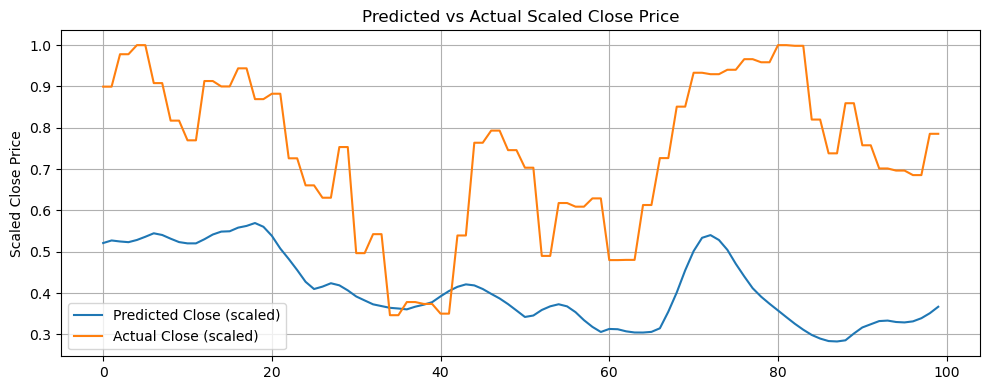

In [68]:
# Predict
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test).float().to(device)
    preds = model(X_test_tensor).cpu().numpy().ravel()

actuals = y_test.ravel()
min_len = min(len(preds), len(actuals))
df_result = pd.DataFrame({
    "Predicted Close (scaled)": preds[:min_len],
    "Actual Close (scaled)": actuals[:min_len]
})

# Plot
df_result.plot(figsize=(10, 4), title="Predicted vs Actual Scaled Close Price")
plt.ylabel("Scaled Close Price")
plt.grid(True)
plt.tight_layout()
plt.show()
